In [1]:
import numpy as np
import pandas as pd
import polars as ps 
import matplotlib.pyplot as plt 
import seaborn as sns
import requests
from sklearn.manifold import TSNE
import random
from tqdm import trange
from IPython.display import display, Markdown
import matplotlib.ticker as mticker


# Datos de expresion de encimas

### Crear los archivos csv desde los datos originales

In [2]:

df_expresion = pd.read_csv("ec_counts.tab.gz", sep="\t", compression="gzip")


FileNotFoundError: [Errno 2] No such file or directory: 'ec_counts.tab.gz'

In [ ]:
## Convertir el archivo de expresion a csv

df_expresion.to_csv("ec_counts.csv", index=False)
print("Archivo convertido a ec_counts.csv")

In [ ]:
## Crear el archivo csv con los datos de las especies

# Descargar datos desde la URL
url = "https://rest.kegg.jp/list/organism"
response = requests.get(url)
data = response.text

# Procesar los datos en un DataFrame
rows = [line.split('\t') for line in data.strip().split('\n')]
df_especies = pd.DataFrame(rows, columns=["TAX_ID", "KEGG_CODE", "SCIENTIFIC_NAME", "TAXONOMY_PATH"])

# Guardar como CSV
df_especies.to_csv("especiesNames.csv", index=False)
print("Archivo especiesNames.csv creado correctamente.")

Archivo especiesNames.csv creado correctamente.


In [ ]:
# Datos de las especies

df_especies = pd.read_csv("especiesNames.csv")

df_especies.head()

,TAX_ID,KEGG_CODE,SCIENTIFIC_NAME,TAXONOMY_PATH
0,T01001,hsa,Homo sapiens (human),Eukaryotes;Animals;Mammals;Primates
1,T01005,ptr,Pan troglodytes (chimpanzee),Eukaryotes;Animals;Mammals;Primates
2,T02283,pps,Pan paniscus (bonobo),Eukaryotes;Animals;Mammals;Primates
3,T02442,ggo,Gorilla gorilla gorilla (western lowland gorilla),Eukaryotes;Animals;Mammals;Primates
4,T01416,pon,Pongo abelii (Sumatran orangutan),Eukaryotes;Animals;Mammals;Primates


### Datos de los csv

In [3]:
df_expresion = pd.read_csv("ec_counts.csv")
df_especies = pd.read_csv("especiesNames.csv")


df_expresion.rename(columns={df_expresion.columns[0]: "KEGG_CODE"}, inplace=True)


# Separar la columna TAXONOMY_PATH en nuevas columnas
taxonomy_split = df_especies["TAXONOMY_PATH"].str.split(";", expand=True)

# Asignar nombres y rellenar faltantes con "0"
df_especies["Dominio"] = taxonomy_split[0].fillna("0")
df_especies["Reino"]   = taxonomy_split[1].fillna("0")
df_especies["Clase"]   = taxonomy_split[2].fillna("0")
df_especies["Orden"]   = taxonomy_split[3].fillna("0")

# Mostrar las primeras filas para verificar
print(df_especies[["TAX_ID", "KEGG_CODE", "SCIENTIFIC_NAME", "Dominio", "Reino", "Clase", "Orden"]].head())

   TAX_ID KEGG_CODE                                    SCIENTIFIC_NAME  \
0  T01001       hsa                               Homo sapiens (human)   
1  T01005       ptr                       Pan troglodytes (chimpanzee)   
2  T02283       pps                              Pan paniscus (bonobo)   
3  T02442       ggo  Gorilla gorilla gorilla (western lowland gorilla)   
4  T01416       pon                  Pongo abelii (Sumatran orangutan)   

      Dominio    Reino    Clase     Orden  
0  Eukaryotes  Animals  Mammals  Primates  
1  Eukaryotes  Animals  Mammals  Primates  
2  Eukaryotes  Animals  Mammals  Primates  
3  Eukaryotes  Animals  Mammals  Primates  
4  Eukaryotes  Animals  Mammals  Primates  


In [3]:

# Agregar columna "especie" a df_expresion usando el nombre científico de df_especies
df_expresion["especie"] = df_expresion["KEGG_CODE"].map(
    df_especies.set_index("KEGG_CODE")["SCIENTIFIC_NAME"]
)

# Reordenar columnas para que "especie" esté después de "KEGG_CODE"
cols = list(df_expresion.columns)
cols.insert(cols.index("KEGG_CODE") + 1, cols.pop(cols.index("especie")))
df_expresion = df_expresion[cols]


In [ ]:
# Creo otro target para clasificar segun el tax 2

trgtTax2 = pd.merge(
    df_expresion[["KEGG_CODE"]],  # columna KEGG_CODE de df_expresion
    df_especies[["KEGG_CODE", "Reino"]],  # columna Reino de df_especies
    on="KEGG_CODE",
    how="inner"  # o "inner" si quieres solo los que están en ambos
)


print(trgtTax2)

In [8]:
trgtTax2.to_csv("trgtTax2.csv", index=False)

In [11]:
# Balanceo el target y el expresion

# Contar cuántos hay de cada tipo
conteo = trgtTax2["Reino"].value_counts()

# Obtener el tamaño del segundo grupo más grande
tamaño_segundo = sorted(conteo.values, reverse=True)[1]

# Submuestrear bacterias para balancear
bacterias = trgtTax2[trgtTax2["Reino"] == "Bacteria"]
otros = trgtTax2[trgtTax2["Reino"] != "Bacteria"]
bacterias_bal = bacterias.sample(n=tamaño_segundo, random_state=42)

# Combinar balanceado
trgtTax_bal = pd.concat([bacterias_bal, otros], ignore_index=True)

# Verificar resultado
print(trgtTax_bal["Reino"].value_counts())


## Expresion balanceada

# Filtrar df_expresion para conservar solo los KEGG_CODE balanceados
df_expresion_bal = df_expresion[df_expresion["KEGG_CODE"].isin(trgtTax_bal["KEGG_CODE"])].copy()

# Verificar el tamaño resultante
print(df_expresion_bal.shape)
print(df_expresion_bal.head())


Reino
Bacteria    552
Animals     552
Archaea     407
Fungi       154
Plants      143
Protists     55
Name: count, dtype: int64
(1863, 4949)
  KEGG_CODE  ec:3.1.1.31  ec:3.6.5.4  ec:3.5.4.6  ec:3.2.1.1  ec:1.4.3.21  \
0       mmu            2           3           3           6            2   
1       bta            1           1           3           2            4   
2       ely            2           1           5           3            2   
3      plep            2           0           5           2            2   
4      aplc            2           1           2           6            0   

   ec:3.5.3.1  ec:6.3.4.5  ec:2.3.2.8  ec:2.7.11.1  ...  ec:1.1.1.268  \
0           2           1           1          219  ...             0   
1           2           1           1          223  ...             0   
2           2           1           1          284  ...             0   
3           2           1           1          278  ...             0   
4           1           1      

In [ ]:
trgtTax_bal.to_csv("trgtTax2_balanced.csv", index=False)
df_expresion_bal.to_csv("df_expresion_balanced.csv", index=False)

In [ ]:

# Visualizo mis datos finales 

print("Tamaño de los datos de expresión:",df_expresion.shape)
print(df_expresion.head())

print("Tamaño de los datos de especies:",df_especies.shape)
print(df_especies.head())


Tamaño de los datos de expresión: (9067, 4950)
  KEGG_CODE                                        especie  ec:3.1.1.31  \
0       mmu                     Mus musculus (house mouse)            2   
1       bta                               Bos taurus (cow)            1   
2       ely        Epinephelus lanceolatus (giant grouper)            2   
3      plep  Plectropomus leopardus (leopard coralgrouper)            2   
4      aplc  Acanthaster planci (crown-of-thorns starfish)            2   

   ec:3.6.5.4  ec:3.5.4.6  ec:3.2.1.1  ec:1.4.3.21  ec:3.5.3.1  ec:6.3.4.5  \
0           3           3           6            2           2           1   
1           1           3           2            4           2           1   
2           1           5           3            2           2           1   
3           0           5           2            2           2           1   
4           1           2           6            0           1           1   

   ec:2.3.2.8  ...  ec:1.1.1.268 

In [5]:
df_expresion.describe()

,ec:3.1.1.31,ec:3.6.5.4,ec:3.5.4.6,ec:3.2.1.1,ec:1.4.3.21,ec:3.5.3.1,ec:6.3.4.5,ec:2.3.2.8,ec:2.7.11.1,ec:7.6.2.1,...,ec:1.1.1.268,ec:2.5.1.94,ec:4.2.3.199,ec:2.3.1.172,ec:2.3.1.140,ec:4.2.3.186,ec:5.5.1.28,ec:2.3.1.214,ec:2.1.1.385,ec:3.4.22.51
count,9067.000000,9067.000000,9067.000000,9067.000000,9067.000000,9067.000000,9067.000000,9067.000000,9067.000000,9067.000000,...,9067.000000,9067.000000,9067.000000,9067.000000,9067.000000,9067.000000,9067.000000,9067.000000,9067.000000,9067.000000
mean,1.016874,1.028234,0.229955,0.910886,0.345980,0.425609,0.877909,0.103342,19.270211,1.034300,...,0.000110,0.000110,0.000551,0.000110,0.000221,0.000221,0.000110,0.000110,0.000110,0.000993
std,0.998257,0.481144,0.858481,1.424859,1.239634,0.674990,0.447293,0.350564,55.400356,3.707279,...,0.010502,0.010502,0.052510,0.010502,0.021004,0.021004,0.010502,0.010502,0.010502,0.094517
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,6.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,20.000000,16.000000,12.000000,34.000000,16.000000,6.000000,8.000000,6.000000,610.000000,42.000000,...,1.000000,1.000000,5.000000,1.000000,2.000000,2.000000,1.000000,1.000000,1.000000,9.000000


In [6]:

# Selecciona solo las columnas numéricas (excluyendo KEGG_CODE y especie)
cols_numericas = df_expresion.select_dtypes(include=[float, int]).columns
X = df_expresion[cols_numericas]

# Aplica t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_embedded = tsne.fit_transform(X)

# Agrega los resultados al DataFrame
df_expresion["TSNE_1"] = X_embedded[:, 0]
df_expresion["TSNE_2"] = X_embedded[:, 1]

print(df_expresion[["KEGG_CODE", "especie", "TSNE_1", "TSNE_2"]].head())

  KEGG_CODE                                        especie     TSNE_1  \
0       mmu                     Mus musculus (house mouse)  67.779922   
1       bta                               Bos taurus (cow)  63.400860   
2       ely        Epinephelus lanceolatus (giant grouper)  83.583267   
3      plep  Plectropomus leopardus (leopard coralgrouper)  82.261917   
4      aplc  Acanthaster planci (crown-of-thorns starfish)  82.775040   

      TSNE_2  
0 -45.284817  
1 -48.315296  
2 -38.589043  
3 -38.744717  
4 -10.264495  


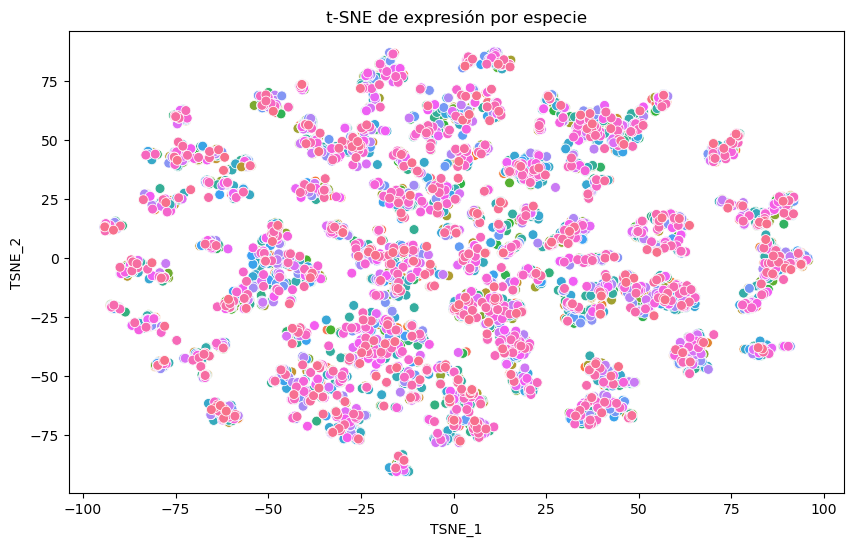

In [8]:

# Graficar los resultados de t-SNE con seaborn
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_expresion,
    x="TSNE_1",
    y="TSNE_2",
    hue="especie",
    legend=False,
    s=50
)
plt.title("t-SNE de expresión por especie")
plt.xlabel("TSNE_1")
plt.ylabel("TSNE_2")
plt.show()

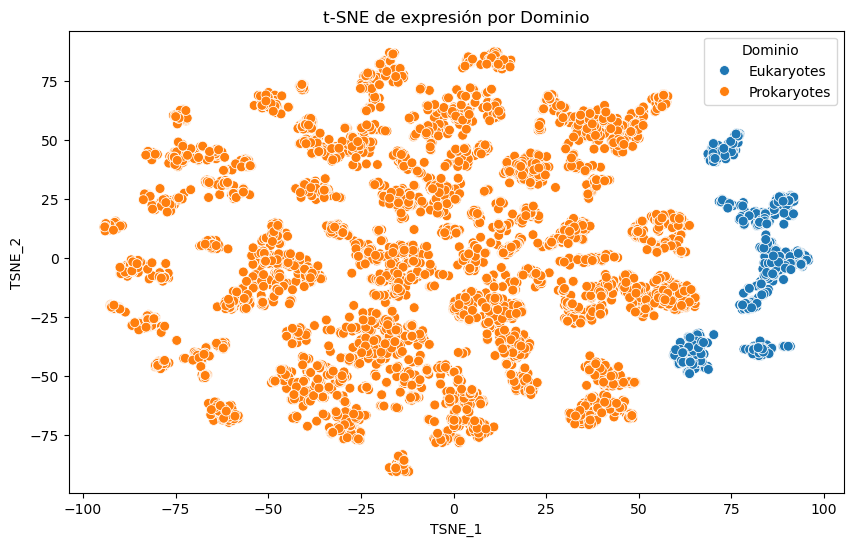

In [9]:
# ...existing code...
df_expresion = df_expresion.copy()  # Asegura que es una copia

df_expresion["Dominio"] = df_expresion["KEGG_CODE"].map(
    df_especies.set_index("KEGG_CODE")["Dominio"]
)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_expresion,
    x="TSNE_1",
    y="TSNE_2",
    hue="Dominio",
    palette="tab10",
    s=50
)
plt.title("t-SNE de expresión por Dominio")
plt.xlabel("TSNE_1")
plt.ylabel("TSNE_2")
plt.legend(title="Dominio")
plt.show()

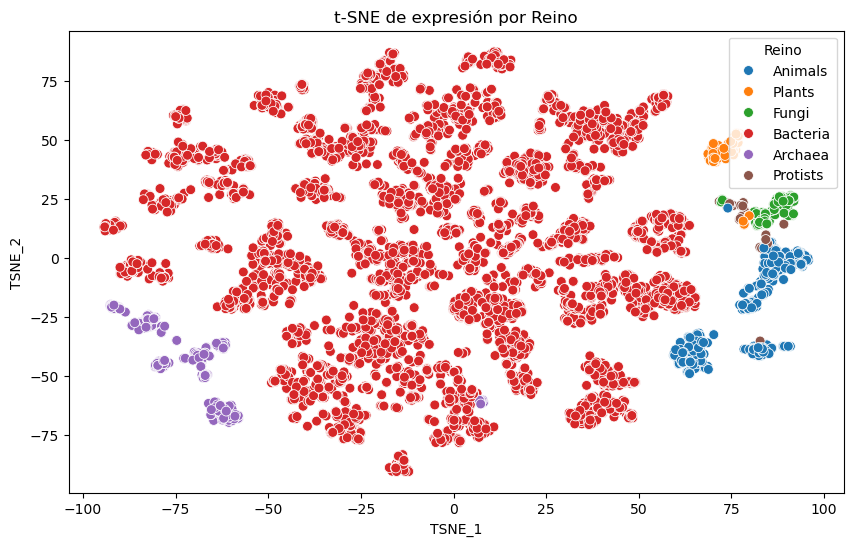

In [10]:
# Asegura que df_expresion es una copia
df_expresion = df_expresion.copy()

# Asignar Reino, Clase y Orden usando KEGG_CODE
df_expresion["Reino"] = df_expresion["KEGG_CODE"].map(
    df_especies.set_index("KEGG_CODE")["Reino"]
)
df_expresion["Clase"] = df_expresion["KEGG_CODE"].map(
    df_especies.set_index("KEGG_CODE")["Clase"]
)
df_expresion["Orden"] = df_expresion["KEGG_CODE"].map(
    df_especies.set_index("KEGG_CODE")["Orden"]
)

# Visualización t-SNE por Reino
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_expresion,
    x="TSNE_1",
    y="TSNE_2",
    hue="Reino",
    palette="tab10",
    s=50
)
plt.title("t-SNE de expresión por Reino")
plt.xlabel("TSNE_1")
plt.ylabel("TSNE_2")
plt.legend(title="Reino")
plt.show()


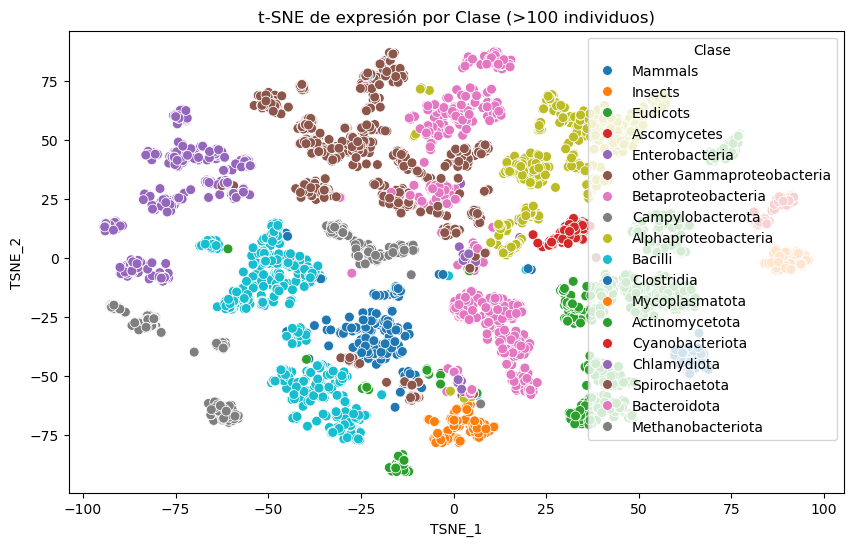

In [11]:
# ...existing code...
# Cuenta de individuos por Clase
conteo_clase = df_expresion["Clase"].value_counts()

# Filtra las clases con más de 100 individuos
clases_mayores_100 = conteo_clase[conteo_clase > 100].index
df_filtrado = df_expresion[df_expresion["Clase"].isin(clases_mayores_100)]

# Visualización t-SNE solo para clases con más de 100 individuos
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_filtrado,
    x="TSNE_1",
    y="TSNE_2",
    hue="Clase",
    palette="tab10",
    s=50
)
plt.title("t-SNE de expresión por Clase (>100 individuos)")
plt.xlabel("TSNE_1")
plt.ylabel("TSNE_2")
plt.legend(title="Clase")

In [12]:
# ...existing code...
# Cuenta de individuos por Clase
conteo_clase = df_expresion["Clase"].value_counts()
print(conteo_clase)
conteo_clase.mean()

Clase
Actinomycetota               1177
other Gammaproteobacteria    1154
Bacilli                      1058
Alphaproteobacteria           934
Enterobacteria                594
                             ... 
Omnitrophota                    1
Cloacimonadota                  1
Calditrichota                   1
Melainabacteria                 1
other Metazoa                   1
Name: count, Length: 97, dtype: int64


np.float64(93.42268041237114)

In [17]:
print(target)

     KEGG_CODE      Dominio
0          mmu   Eukaryotes
1          bta   Eukaryotes
2          ely   Eukaryotes
3         plep   Eukaryotes
4         aplc   Eukaryotes
...        ...          ...
9062       cwn  Prokaryotes
9063       orn  Prokaryotes
9064       lgo  Prokaryotes
9065      mpau  Prokaryotes
9066       hls  Prokaryotes

[9067 rows x 2 columns]


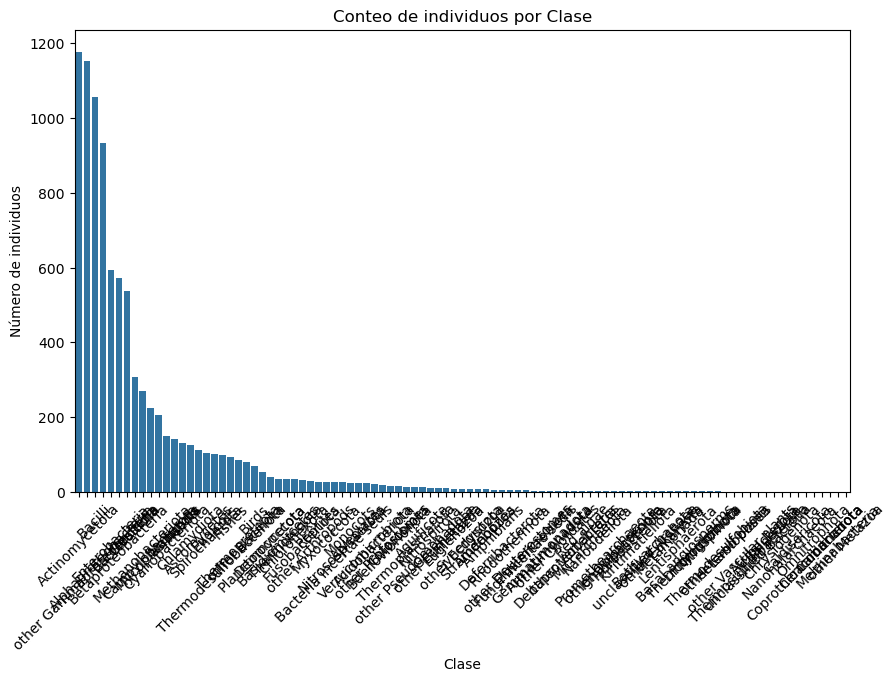

In [13]:
plt.figure(figsize=(10, 6))
sns.barplot(x=conteo_clase.index, y=conteo_clase.values)
plt.title("Conteo de individuos por Clase")
plt.xlabel("Clase")
plt.ylabel("Número de individuos")
plt.xticks(rotation=45)
plt.show()

# Algoritmo Genético


In [7]:
%load_ext autoreload
%autoreload 2


In [6]:
import numpy as np
import pandas as pd
import random
from tqdm import trange

import algoritmo_genetico as ag


from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score



In [ ]:
df_expresion = pd.read_csv("df_expresion.csv")
target = pd.read_csv("target.csv")

## Función Objetivo

In [ ]:

def fitness(cromosoma, df_expresion, target, modelo="rf", metric="accuracy",
            test_size=0.2, random_state=42):
    
    """
    Evalúa un cromosoma (lista de índices de columnas de df_expresion) usando
    df_expresion y target proporcionados como parámetros.

    Para que la función de fitness funcione correctamente:
    - df_expresion: DataFrame con las muestras en filas y los genes en columnas.
    - target: DataFrame con dos columnas, donde la primera contiene los identificadores de las muestras
    y la segunda la clase de cada muestra (por ejemplo, 'eukarionte' o 'procarionte').

    Modelo: este parametro define el modelo de clasificación a usar "rf" para Random Forest o "svm" para una Maquina de Soporte Vectorial.
    """

    X_full = df_expresion
    tgt = target

    # Seleccionar genes válidos (filtrar -1 y fuera de rango)
    selected_idx = [i for i in cromosoma if isinstance(i, int) and 0 <= i < X_full.shape[1]]
    if len(selected_idx) == 0:
        return 0.0  # sin genes seleccionados -> fitness malo

    genes = X_full.columns[selected_idx]

    # Alinear target con df_expresion
    id_col, class_col = tgt.columns[0], tgt.columns[1]
    try:
        if set(X_full.index).intersection(set(tgt.iloc[:,0])):
            target_series = tgt.set_index(id_col)[class_col].reindex(X_full.index)
        elif len(tgt) == len(X_full):
            target_series = tgt.iloc[:, 1].reset_index(drop=True)
            target_series.index = X_full.index
        else:
            raise ValueError("No puedo alinear `target` con `df_expresion`.")
    except Exception as e:
        raise ValueError(f"Error alineando target: {e}")

    mask_valid = target_series.notna()
    if mask_valid.sum() == 0:
        return 0.0

    X = X_full.loc[mask_valid, genes]
    y = target_series.loc[mask_valid]

    # Codificar etiquetas (binario)
    le = LabelEncoder()
    y_enc = le.fit_transform(y.astype(str))
    if len(np.unique(y_enc)) != 2:
        return 0.0

    # Partición y escalado
    stratify = y_enc
    X_train, X_test, y_train, y_test = train_test_split(
        X.values, y_enc, test_size=test_size, random_state=random_state, stratify=stratify
    )
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Modelo
    if modelo == "rf":
        clf = RandomForestClassifier(n_estimators=100, random_state=random_state)
    elif modelo == "svm":
        clf = SVC(kernel="linear", probability=True, random_state=random_state)
    else:
        raise ValueError("Modelo no soportado: 'rf' o 'svm'.")

    clf.fit(X_train, y_train)

    # Predicción y métrica
    y_pred = clf.predict(X_test)
    if metric == "accuracy":
        score = accuracy_score(y_test, y_pred)
    elif metric == "f1":
        score = f1_score(y_test, y_pred)
    elif metric == "roc_auc":
        if hasattr(clf, "predict_proba"):
            y_proba = clf.predict_proba(X_test)[:, 1]
            score = roc_auc_score(y_test, y_proba)
        else:
            try:
                y_scores = clf.decision_function(X_test)
                score = roc_auc_score(y_test, y_scores)
            except Exception:
                score = accuracy_score(y_test, y_pred)
    else:
        raise ValueError("Métrica no soportada: 'accuracy', 'f1' o 'roc_auc'.")

    return float(score)


variante corregida


In [ ]:

def fitness(cromosoma, df_expresion, target, modelo="rf", metric="accuracy",
            test_size=0.2, random_state=42, cv=5):
    """
    Evalúa un cromosoma (lista de índices de columnas de df_expresion) usando
    df_expresion y target proporcionados como parámetros.

    Si modelo="rf", usa evaluación OOB.
    Si modelo="svm", usa validación cruzada k-fold.
    """

    X_full = df_expresion
    tgt = target

    # Seleccionar genes válidos
    selected_idx = [i for i in cromosoma if isinstance(i, int) and 0 <= i < X_full.shape[1]]
    if len(selected_idx) == 0:
        return 0.0
        
    genes = X_full.columns[selected_idx]

    # Alinear target
    id_col, class_col = tgt.columns[0], tgt.columns[1]
    try:
        if set(X_full.index).intersection(set(tgt.iloc[:,0])):
            target_series = tgt.set_index(id_col)[class_col].reindex(X_full.index)
        elif len(tgt) == len(X_full):
            target_series = tgt.iloc[:, 1].reset_index(drop=True)
            target_series.index = X_full.index
        else:
            raise ValueError("No puedo alinear `target` con `df_expresion`.")
    except Exception as e:
        raise ValueError(f"Error alineando target: {e}")

    mask_valid = target_series.notna()
    if mask_valid.sum() == 0:
        return 0.0

    X = X_full.loc[mask_valid, genes]
    y = target_series.loc[mask_valid]

    # Codificar etiquetas
    le = LabelEncoder()
    y_enc = le.fit_transform(y.astype(str))
    if len(np.unique(y_enc)) != 2:
        return 0.0

    # Escalado
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X.values)

    # Modelo y evaluación
    if modelo == "rf":
        clf = RandomForestClassifier(
            n_estimators=100,
            random_state=random_state,
            oob_score=True,
            bootstrap=True
        )
        clf.fit(X_scaled, y_enc)
        score = clf.oob_score_

    elif modelo == "svm":
        clf = SVC(kernel="linear", probability=True, random_state=random_state)
        scoring = metric if metric in ["accuracy", "f1", "roc_auc"] else "accuracy"
        scores = cross_val_score(clf, X_scaled, y_enc, cv=cv, scoring=scoring)
        score = np.mean(scores)

    else:
        raise ValueError("Modelo no soportado: 'rf' o 'svm'.")

    return float(score)


Evolución AG: 100%|██████████| 20/20 [02:10<00:00,  6.51s/it]


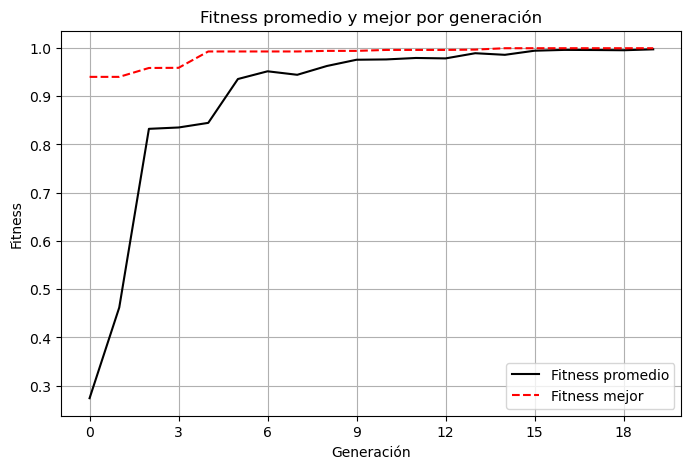

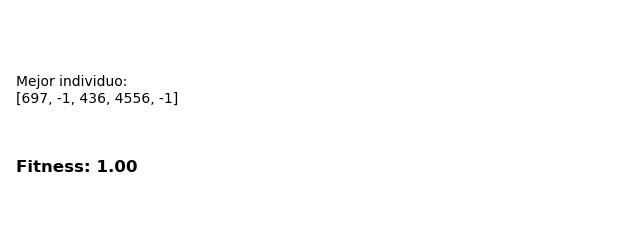

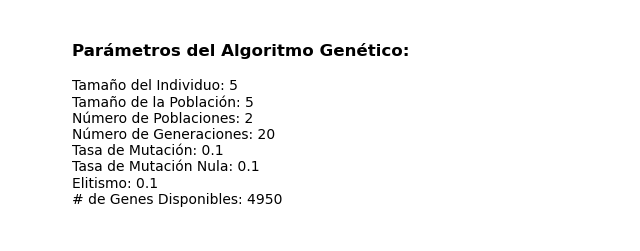

In [ ]:


# ------------------------------
# Definir genes disponibles
# ------------------------------
LEGO = list(range(4950))  # ajusta según tu dataset

# ------------------------------
# Ejecutar el Algoritmo Genético
# ------------------------------

df_historial, mejores, mejor_global, parametros = ag.algoritmo_genetico(
    fitness_func=fitness,
    modo=1,
    LEGO=LEGO,
    IND_LEN=5,
    POP_SIZE=5,
    POP_NUM=2,
    GENS=20,
    MUT_RATE=0.1,
    MUT_NULL_RATE=0.1,
    ELITISM=0.1,
    df_expresion=df_expresion,
    target=target,
    modelo="rf",
    metric="accuracy",
    test_size=0.2,
    random_state=42
)

# ------------------------------
# Visualización de resultados
# ------------------------------
ag.plot_ag_results(df_historial, mejor_global, fitness, parametros,
                   df_expresion=df_expresion, target=target, modelo="rf", metric="accuracy")
